<a href="https://colab.research.google.com/github/LleilaA13/FDS25-26/blob/main/classnotes/FDS_NonParametricMethods.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Section 1: K-NN**

## K-NN from scratch

In this first part of the notebook we will:
1. Generate a **synthetic 2D dataset** with two classes.  
2. Implement the **K-NN algorithm from scratch** using only NumPy.  
3. Visualize how the **decision boundary** changes for different values of *k*.  

K-NN is a **non-parametric**, **instance-based** learning algorithm.  
Given a new point, it looks at the *k* closest training samples and predicts the label by majority vote.

**Step 1 - Generate synthetic 2D dataset**

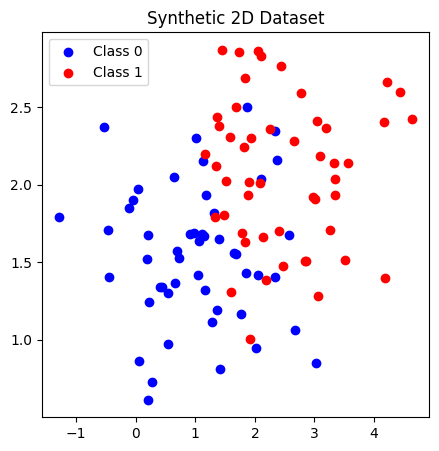

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

# Step 1: Generate synthetic 2D dataset

np.random.seed(0)  # for reproducibility

# Mean and covariance of the two Gaussian clusters
mean1, mean2 = [1, 1.5], [2.5, 2]
cov = [[0.8, 0], [0, 0.2]]  # covariance matrix (spread of points)

# Sample 50 points from each Gaussian
X_class0 = np.random.multivariate_normal(mean1, cov, 50)
X_class1 = np.random.multivariate_normal(mean2, cov, 50)

# Stack them into one dataset
X = np.vstack((X_class0, X_class1))
y = np.array([0] * 50 + [1] * 50)  # labels: 0 for class0, 1 for class1

# Visualize the data
plt.figure(figsize=(5, 5))
plt.scatter(X_class0[:, 0], X_class0[:, 1], c='blue', label='Class 0')
plt.scatter(X_class1[:, 0], X_class1[:, 1], c='red', label='Class 1')
plt.title('Synthetic 2D Dataset')
plt.legend()
plt.show()

**Step 2 — Implementing K-NN**

We now define:
- A helper function to compute **Euclidean distance** between two points.
- The main **`knn_predict`** function that:
  1. Finds the *k* nearest neighbors of a test point.
  2. Retrieves their labels.
  3. Returns the most common label.


In [ ]:
# Step 2: Define helper functions

def euclidean_distance(a, b):
    """Compute the Euclidean distance between two vectors a and b."""
    return np.sqrt(np.sum((a - b) ** 2))

def knn_predict(X_train, y_train, x_test, k=3):
    """Predict the class of x_test using the KNN algorithm."""
    # Compute distance from test point to every training point
    distances = [euclidean_distance(x_test, x_i) for x_i in X_train] # --> list comprehension !!

    # Take indices of the k smallest distances
    k_idx = np.argsort(distances)[:k]

    # Retrieve the labels of the k nearest points
    k_labels = [y_train[i] for i in k_idx]

    # Return the most frequent label
    most_common = Counter(k_labels).most_common(1)
    return most_common[0][0]

**(BONUS for your future: List Comprehension)**

In [ ]:
# --- Standard For Loop ---
squares = []
for i in range(10):
    squares.append(i**2)

# --- List comprehension ---
#      Pls study this :)
squares_comp = [i**2 for i in range(10)]

# ----
print("For loop:", squares)
print("List comprehension:", squares_comp)

For loop: [0, 1, 4, 9, 16, 25, 36, 49, 64, 81]
List comprehension: [0, 1, 4, 9, 16, 25, 36, 49, 64, 81]


**Step 3 — Visualizing Decision Boundaries**

We can visualize how the **decision regions** change for different values of *k*.
- Small *k* → more flexible, may overfit.  
- Large *k* → smoother boundary, may underfit.

We’ll use a mesh grid and color each point according to the class predicted by our `knn_predict` function.


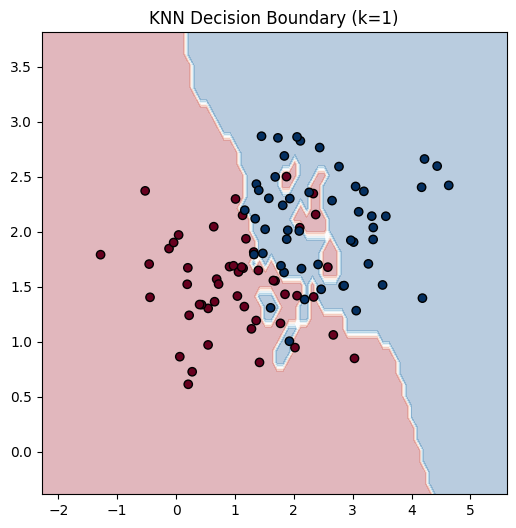

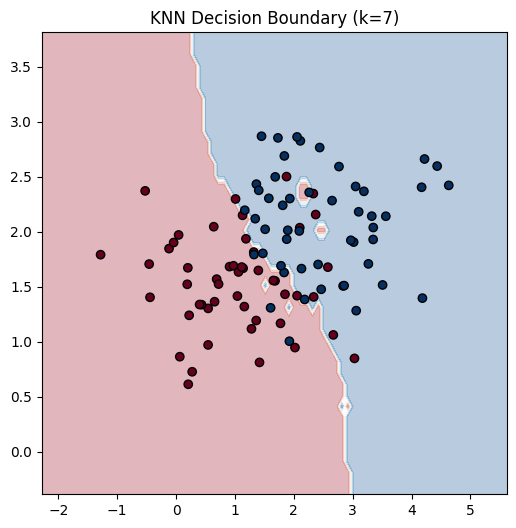

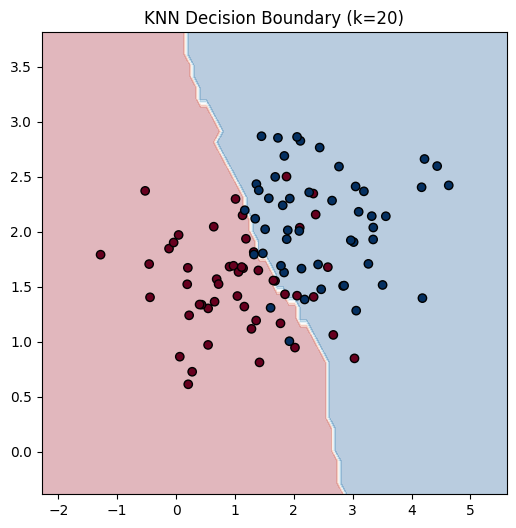

In [ ]:
# Step 3: Plot decision boundaries

def plot_decision_boundary(X, y, k=3, h=0.1):
    """Visualize the KNN decision boundary for a given k."""

    # Define grid range
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))

    # Predict class for every grid point
    Z = np.array([knn_predict(X, y, np.array([x, yv]), k)
                  for x, yv in zip(xx.ravel(), yy.ravel())])
    Z = Z.reshape(xx.shape)

    # Plot filled contours and data points
    plt.figure(figsize=(6, 6))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.RdBu)
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdBu, edgecolor='k')
    plt.title(f'KNN Decision Boundary (k={k})')
    plt.show()

# Try different k values to see the effect
for k in [1, 7, 20]:
    plot_decision_boundary(X, y, k)

## Part 2: K-NN with sklearn

Now that we implemented K-NN from scratch,  
let’s use the **`scikit-learn`** library to apply it on a real dataset: the **Iris dataset**.

This will let us:
1. Train and evaluate a `KNeighborsClassifier`.
2. Visualize its performance with a **confusion matrix**.
3. Analyze how the accuracy changes as *k* varies.


In [ ]:
from sklearn.datasets import load_iris
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# --- Step 1: Load the dataset ---
data = load_iris()
X, y = data.data, data.target  # features and labels

# --- Step 2: Train-test split ---
# 70% for training, 30% for testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

**Training the Model**

We now create an instance of `KNeighborsClassifier` with:
- `n_neighbors=5` (we’ll later vary it),
- default Euclidean distance.

Then, we fit it on the training data.

In [ ]:
# --- Step 3: Train KNN classifier ---
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

KNeighborsClassifier()

**Evaluate the Model**

We can now:
1. Compute the **accuracy** on the test set.  
2. Plot the **confusion matrix** to see where the model misclassifies.

Accuracy: 1.000


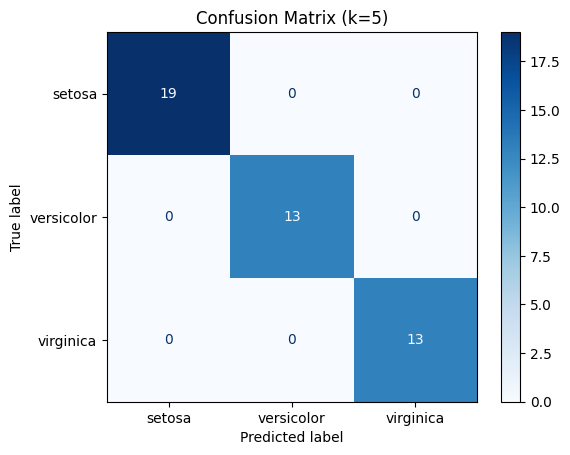

In [ ]:
# --- Step 4: Evaluate model ---

# Predict labels for the test set
y_pred = knn.predict(X_test)

# Compute accuracy
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc:.3f}")

# Plot confusion matrix
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=data.target_names).plot(cmap='Blues')
plt.title("Confusion Matrix (k=5)")
plt.show()

**Analyzing the Effect of *k***

The choice of *k* affects the model’s bias-variance trade-off:
- **Small k** → low bias, high variance (risk of overfitting).  
- **Large k** → high bias, low variance (risk of underfitting).

Let's test multiple *k* values and perform **5-fold cross-validation** to estimate accuracy:

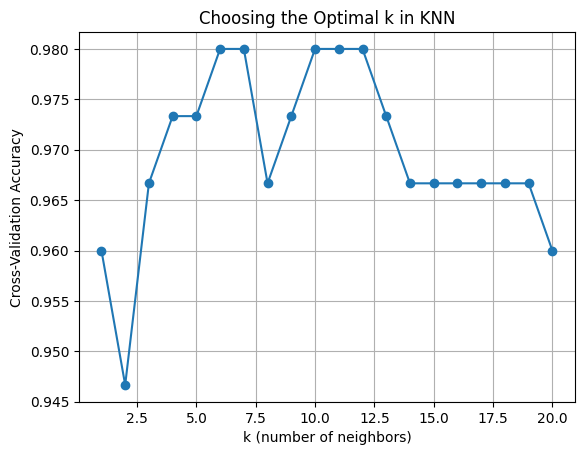

In [ ]:
# --- Step 5: Analyze performance as k varies ---

ks = range(1, 21)
# Compute 5-fold cross-validation accuracy for each k
scores = [
    cross_val_score(KNeighborsClassifier(n_neighbors=k), X, y, cv=5).mean()
    for k in ks
] # remember: we imported the cross_validation_score from sklearn.model_selection

# Plot accuracy vs k
plt.plot(ks, scores, marker='o')
plt.xlabel('k (number of neighbors)')
plt.ylabel('Cross-Validation Accuracy')
plt.title('Choosing the Optimal k in KNN')
plt.grid(True)
plt.show()

**Summary**

- `scikit-learn` provides a simple and efficient implementation of K-NN.
- Increasing *k* too much smooths the boundaries and can reduce precision.

**Next steps for you 🫵🏻:**  
Try other datasets or distance metrics (e.g., Manhattan, Minkowski) using the `metric` parameter in `KNeighborsClassifier`.

# **Section 2: Decision Trees**

In this section, we explore **Decision Trees** for classification.

We will:
1. Train a simple Decision Tree on the Iris dataset.  
2. Compare **Gini impurity** and **Entropy** criteria.  
3. Study how **tree depth** affects model complexity.  
4. Apply **cost-complexity pruning** to reduce overfitting.  

Decision Trees are powerful, interpretable models that recursively split the data to maximize class purity.

### Decision Trees: Intro + Gini vs Entropy

**What is a Decision Tree**
A Decision Tree is a supervised model for classification or regression.  
It recursively splits the data with simple rules like `feature_j < threshold` to create regions that are as *pure* as possible.  
- Internal node: a decision rule.  
- Edge: outcome of the rule.  
- Leaf: predicted class (classification) or value (regression).

Goal at each node: pick the feature and threshold that **maximally reduce impurity**.

---

**Impurity Measures**

Let $p_i$ be the class proportion of class $i$ among $C$ classes in a node.

#### Gini Impurity:
$$
G = 1 - \sum_{i=1}^{C} p_i^2
$$
- $G=0$ if the node is pure (in fact, this happens when all the samples belong to one class).  
- Interpretable as the probability of mislabeling a sample if you label it at random according to the node’s class distribution.  
- Fast to compute.

**Example 1**: (70% A, 30% B):  
$$
G = 1 - (0.7^2 + 0.3^2) = 0.42 😾
$$

**Example 2**: (100% A, 0% B):  
$$
G = 1 - (1.0^2 + 0^2) = 1 - 1 = 0 😸
$$


#### Entropy:
$$
H = - \sum_{i=1}^{C} p_i \log_2 p_i
$$
- $H=0$ if the node is pure.  
- Measures the expected number of bits needed to identify the class (uncertainty).  

**Example:** (70% A, 30% B):  
$$
H = -\big(0.7\log_2 0.7 + 0.3\log_2 0.3\big) \approx 0.88
$$

---

## Using Impurity to Choose a Split

For a candidate split that partitions a parent node $P$ into children $\{C_k\}$ with sizes $|C_k|$:
$$
\text{ImpurityDecrease} = I(P) - \sum_k \frac{|C_k|}{|P|} \, I(C_k)
$$
where $I(\cdot)$ is either **Gini** or **Entropy**.  
Choose the split with the **largest impurity decrease** (a.k.a. information gain for Entropy).

---

## Practical Notes
- **Gini** (CART, default in scikit-learn) and **Entropy** (ID3/C4.5) often yield similar trees.  
- Gini is slightly faster (no log).  
- Entropy can favor more balanced splits when class proportions differ.  
- Control overfitting with constraints: `max_depth`, `min_samples_leaf`, `ccp_alpha` (cost-complexity pruning).

---

## Quick Reference

| Measure  | Formula                          | Range      | Intuition                                      | Common use |
|----------|----------------------------------|------------|-----------------------------------------------|------------|
| Gini     | $1 - \sum p_i^2$               | $[0, 1 - 1/C]$ | Random-label misclassification probability      | CART       |
| Entropy  | $-\sum p_i \log_2 p_i$         | $[0, \log_2 C]$ | Expected bits to resolve class uncertainty      | ID3/C4.5   |

Accuracy (Gini): 1.000


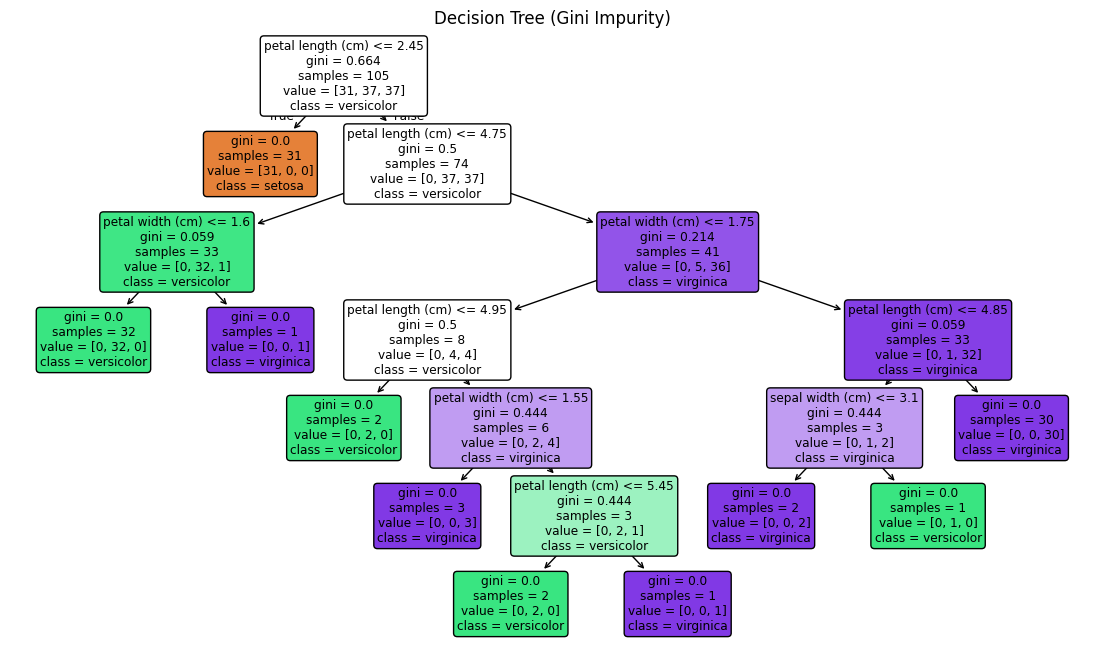

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris, make_moons
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score

# --- Step 1: Load a dataset (Iris for multi-class classification) ---
data = load_iris()
X, y = data.data, data.target
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# --- Step 2: Train a basic Decision Tree ---
clf = DecisionTreeClassifier(criterion='gini', random_state=42) # --> gini!
clf.fit(X_train, y_train)

# --- Step 3: Evaluate accuracy on the test set ---
y_pred = clf.predict(X_test)
print(f"Accuracy (Gini): {accuracy_score(y_test, y_pred):.3f}")

# --- Step 4: Visualize the tree structure ---
plt.figure(figsize=(14, 8))
plot_tree(
    clf,
    feature_names=data.feature_names,
    class_names=data.target_names,
    filled=True,
    rounded=True
)
plt.title("Decision Tree (Gini Impurity)")
plt.show()

**Comparing Gini and Entropy**

Decision Trees can measure impurity in two ways:
- **Gini impurity** (default): favors larger, more homogeneous nodes.  
- **Entropy** (information gain): tends to create slightly deeper trees.

We’ll compare their accuracy on the same dataset.

In [ ]:
# Train two trees with different impurity criteria
clf_gini = DecisionTreeClassifier(criterion='gini', random_state=42)
clf_entropy = DecisionTreeClassifier(criterion='entropy', random_state=42)

clf_gini.fit(X_train, y_train)
clf_entropy.fit(X_train, y_train)

# Compute accuracy for both models
acc_gini = accuracy_score(y_test, clf_gini.predict(X_test))
acc_entropy = accuracy_score(y_test, clf_entropy.predict(X_test))

print(f"Gini Accuracy:    {acc_gini:.3f}")
print(f"Entropy Accuracy: {acc_entropy:.3f}")

# This is up to you. For the challenge: explore both possibilities :)

Gini Accuracy:    1.000
Entropy Accuracy: 0.978


## Tree Depth and Model Complexity

The **depth** of a Decision Tree controls how many times it can split the data:
- Small depth → underfitting (high bias).  
- Large depth → overfitting (high variance).

We test different depths and measure cross-validation accuracy.

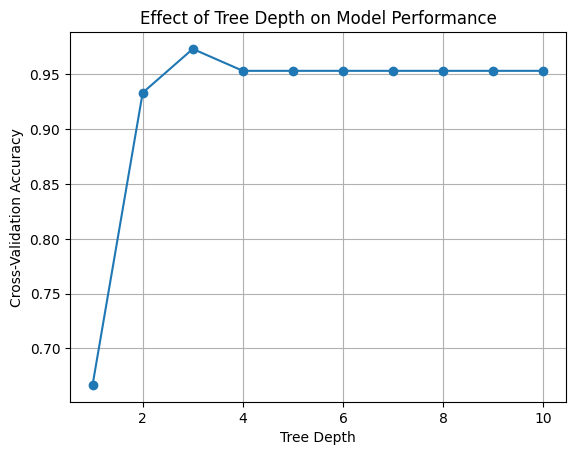

In [ ]:
# Evaluate how model depth influences bias and variance
depths = range(1, 11)
scores = []

for d in depths:
    # On a toy dataset, this is not really evident...
    # But on real world problems, changing the depth can be GAME CHANGING
    tree = DecisionTreeClassifier(max_depth=d, random_state=42)
    score = cross_val_score(tree, X, y, cv=5).mean()
    scores.append(score)

# ------------------------------------------------------
plt.plot(depths, scores, marker='o')
plt.xlabel("Tree Depth")
plt.ylabel("Cross-Validation Accuracy")
plt.title("Effect of Tree Depth on Model Performance")
plt.grid(True)
plt.show()

**Cost-Complexity Pruning**

Decision Trees can easily overfit if grown without constraints.  
**Cost-complexity pruning** reduces tree size by introducing a penalty term (*ccp_alpha*) that balances accuracy and simplicity.

We’ll:
1. Train a large tree.  
2. Evaluate models for increasing values of *ccp_alpha*.  
3. Plot accuracy as a function of *ccp_alpha*.


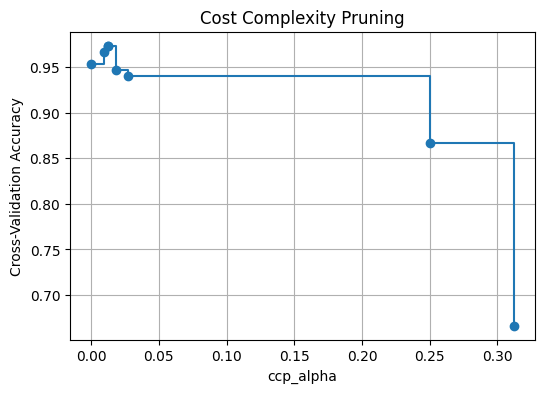

In [ ]:
# Train a large tree first (no depth limit)
clf_full = DecisionTreeClassifier(random_state=42)
clf_full.fit(X_train, y_train)

# Compute effective alphas and impurities for pruning
path = clf_full.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas, impurities = path.ccp_alphas, path.impurities

# Evaluate performance for each alpha using cross-validation
acc_scores = []
for ccp_alpha in ccp_alphas:
    clf_pruned = DecisionTreeClassifier(random_state=42, ccp_alpha=ccp_alpha)
    score = cross_val_score(clf_pruned, X, y, cv=5).mean()
    acc_scores.append(score)

# Plot cross-validation accuracy vs alpha
plt.figure(figsize=(6, 4))
plt.plot(ccp_alphas, acc_scores, marker='o', drawstyle="steps-post")
plt.xlabel("ccp_alpha")
plt.ylabel("Cross-Validation Accuracy")
plt.title("Cost Complexity Pruning")
plt.grid(True)
plt.show()

**Visualizing the Best Pruned Tree**

We now select the *alpha* that maximizes validation accuracy and visualize the resulting **simplified Decision Tree**.


Optimal alpha: 0.01270


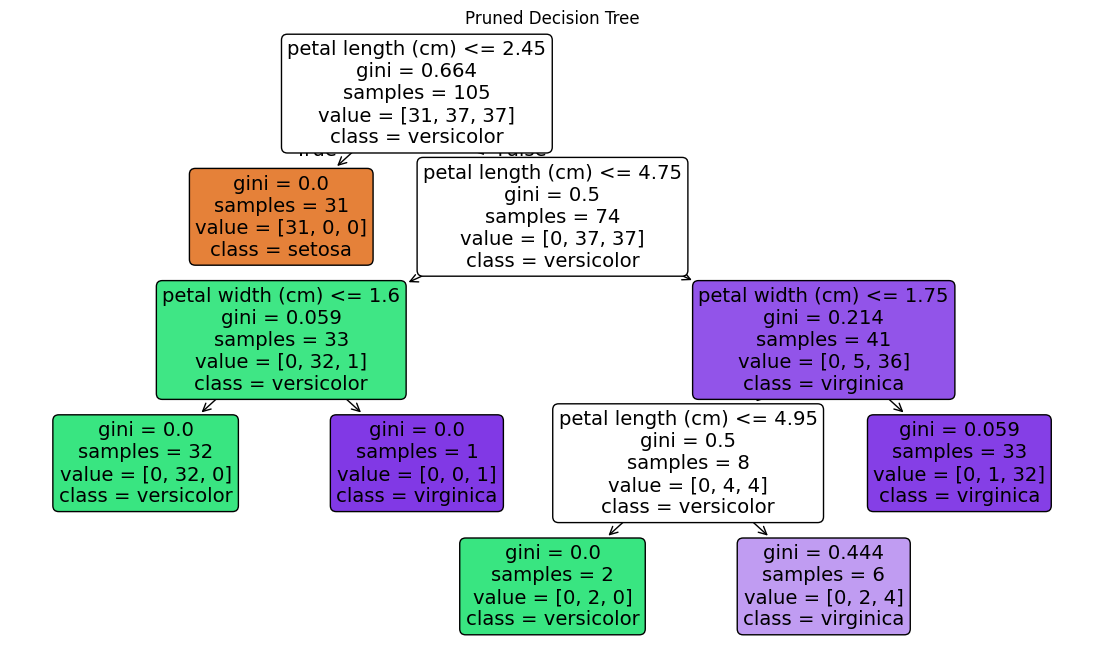

In [ ]:
# Choose alpha that maximizes cross-validation accuracy
best_alpha = ccp_alphas[np.argmax(acc_scores)]
print(f"Optimal alpha: {best_alpha:.5f}")

# Retrain the tree with optimal pruning level
clf_best = DecisionTreeClassifier(random_state=42, ccp_alpha=best_alpha)
clf_best.fit(X_train, y_train)

# Visualize the pruned tree
plt.figure(figsize=(14, 8))
plot_tree(
    clf_best,
    feature_names=data.feature_names,
    class_names=data.target_names,
    filled=True,
    rounded=True
)
plt.title("Pruned Decision Tree")
plt.show()

**Key Takeaways**

- Decision Trees are **interpretable** and **flexible**.  
- **Gini** and **Entropy** often yield similar results.  
- Limiting **depth** or applying **pruning** improves generalization.  
- Pruned trees are more **robust** and **readable**, at minimal loss of accuracy.

Next, we can move to **Ensemble Methods** (Random Forests, Bagging, Boosting) to combine multiple trees for better performance.

# Section 3: Ensemble Learning

Spoiler: this might win the Kaggle Competition 🤧

**Ensemble methods** combine multiple models to improve performance and stability.  
Instead of relying on a single weak learner (like one Decision Tree), we aggregate several models to get a stronger one.

We will explore:
1. **Voting Classifiers** — combine heterogeneous models.  
2. **Bagging and Random Forests** — average many trees trained on random subsets.  
3. **Visualization** — compare decision boundaries.

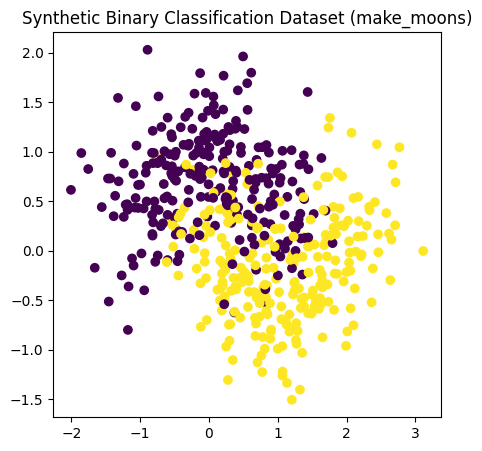

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import VotingClassifier, BaggingClassifier, RandomForestClassifier, AdaBoostClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# --- Step 1: Generate a synthetic binary classification dataset ---
X, y = make_moons(n_samples=500, noise=0.4, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Visualize the dataset
plt.figure(figsize=(5, 5))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap="viridis")
plt.title("Synthetic Binary Classification Dataset (make_moons)")
plt.show()

**Voting Classifier**

The **Voting Classifier** combines different algorithms (e.g., Logistic Regression, SVM, Decision Tree).  
Each model votes for a class, and the final prediction is based on:

- **Hard voting:** majority class.  
- **Soft voting:** average of predicted probabilities (preferred if supported).

This approach reduces variance and leverages complementary model strengths.

In [ ]:
log_clf = LogisticRegression()
tree_clf = DecisionTreeClassifier(max_depth=4, random_state=42)
svm_clf = SVC(probability=True)  # enable probability outputs for soft voting

# Combine classifiers into a single ensemble
voting_clf = VotingClassifier(
    estimators=[
        ('lr', log_clf),
        ('tree', tree_clf),
        ('svm', svm_clf)
    ],
    voting='soft'  # --> average predicted probabilities
)

# Train ensemble
voting_clf.fit(X_train, y_train)

# Evaluate on test set
y_pred = voting_clf.predict(X_test)
print("-"*35)
print(f"Voting Classifier Accuracy: {accuracy_score(y_test, y_pred):.3f}")
print("-"*35)

# Compare with individual models
for name, model in [
    ('Logistic Regression', log_clf),
    ('Decision Tree', tree_clf),
    ('SVM', svm_clf)
]:
    model.fit(X_train, y_train)
    acc = accuracy_score(y_test, model.predict(X_test))
    print(f"{name} Accuracy: {acc:.3f}"); print("-"*35)

# Well... of course this is not great on a toy dataset... but trust me: it really works

-----------------------------------
Voting Classifier Accuracy: 0.853
-----------------------------------
Logistic Regression Accuracy: 0.840
-----------------------------------
Decision Tree Accuracy: 0.847
-----------------------------------
SVM Accuracy: 0.813
-----------------------------------


**Bagging and Random Forest**:
---

### **Bagging (Bootstrap Aggregation)**:
- Trains several models (usually Decision Trees) on random subsets of the training data.
- Averages their predictions → reduces variance and overfitting.

---
#### How Bagging Works — Step by Step

1. You have a dataset with $N$ training samples.  

2. Draw $B$ *bootstrap* subsets, each of size $N$, by **sampling with replacement** from the original data.  

3. Train one model (e.g., a `DecisionTreeClassifier`) on each bootstrap sample independently.  

4. Combine their predictions to form the final ensemble output:  
   - **Classification:** take the **majority vote** across all models.  
   - **Regression:** take the **average** of all predictions.
---

### **Random Forest**:
- Extension of bagging where each tree sees a random subset of features at each split.
- Often performs better and is less correlated among trees.
---

#### How Random Forest Works — Step by Step

1. **Start from Bagging.**  
   A Random Forest is an extension of Bagging that specifically uses **Decision Trees** as base learners.

2. **Bootstrap sampling (data randomness).**  
   For each tree, draw a random bootstrap sample from the training data  
   (sampling **with replacement**), exactly as in Bagging.

3. **Feature randomness (feature subsampling).**  
   When splitting a node, instead of considering *all* features,  
   each tree randomly selects a **subset of features**
   - This prevents all trees from choosing the same dominant features.  
   - It **decorrelates** the trees, further reducing variance.

4. **Grow each tree fully** (no pruning), which allows each to overfit slightly on its own data subset.

5. **Aggregate predictions.**  
   - **Classification:** final class = **majority vote** of all trees.  
   - **Regression:** final value = **average** of all tree outputs.

---

In [ ]:
# Bagging ensemble of Decision Trees
bag_clf = BaggingClassifier(
    DecisionTreeClassifier(),
    n_estimators=100,       # number of trees
    max_samples=0.8,        # each tree sees 80% of training data
    bootstrap=True,         # sample with replacement
    random_state=42
)
bag_clf.fit(X_train, y_train)

# Random Forest (built-in feature randomization)
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)
rf_clf.fit(X_train, y_train)

# Evaluate performance
print(f"Bagging Accuracy: {accuracy_score(y_test, bag_clf.predict(X_test)):.3f}")
print(f"Random Forest Accuracy: {accuracy_score(y_test, rf_clf.predict(X_test)):.3f}")

Bagging Accuracy: 0.813
Random Forest Accuracy: 0.800


**Visualizing Decision Boundaries**

Let’s compare how individual and ensemble models partition the feature space.  
We’ll plot the classification regions for:
- A single Decision Tree  
- Bagging ensemble  
- Random Forest


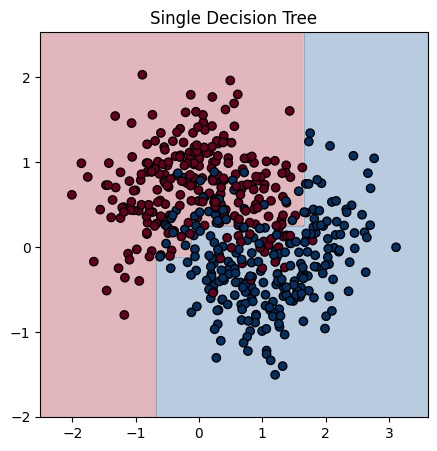

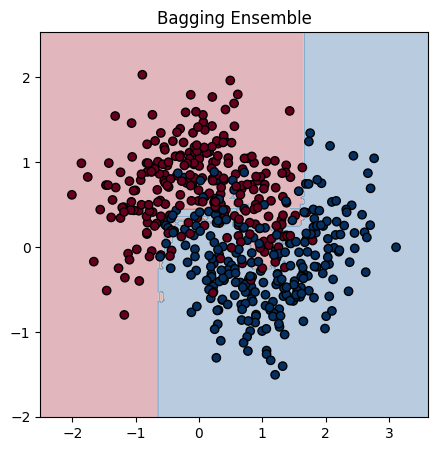

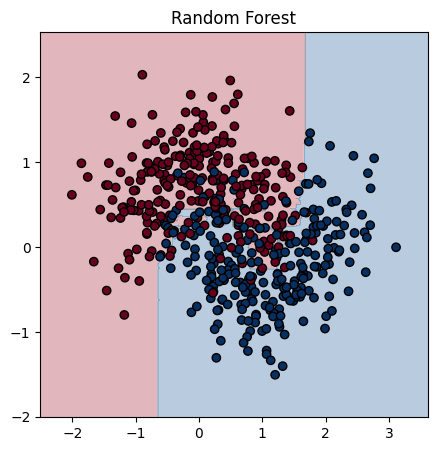

In [ ]:
def plot_decision_boundary(model, X, y, title):
    """Plot 2D decision boundary for a trained classifier."""
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                         np.linspace(y_min, y_max, 300))

    # Predict over grid points
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Plot decision boundary and training points
    plt.figure(figsize=(5, 5))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.RdBu)
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdBu, edgecolor='k')
    plt.title(title)
    plt.show()

# Compare different models visually
plot_decision_boundary(tree_clf.fit(X_train, y_train), X, y, "Single Decision Tree")
plot_decision_boundary(bag_clf, X, y, "Bagging Ensemble")
plot_decision_boundary(rf_clf, X, y, "Random Forest")

## Model Stacking (a.k.a. Stacked Generalization)

**Stacking** is another powerful ensemble method that works in **two levels**.  
Unlike Bagging or Voting, which simply average or count predictions,  
Stacking **learns how to combine models intelligently** by adding a second learning layer — the **meta-model**.

---

### 🧱 How It Works

1. **Base Layer (Level-0 models)**  
   Train several different algorithms on the same training set — for example:  
   - `DecisionTreeClassifier` (captures nonlinear patterns)  
   - `SVC` (good with clear margins)  
   - `LogisticRegression` (stable and interpretable)  
   
   Each model produces its own predictions on the training data.  
   To avoid overfitting, these predictions are typically obtained using **k-fold cross-validation**,  
   so that each base model predicts only on samples it has *not* seen during its own training.

2. **Meta Layer (Level-1 model)**  
   The predictions of the base models become the **input features** for a new model —  
   the *meta-learner* (or *blender*).  
   This meta-model learns how to best combine the outputs of the base models.  
   A common choice is a simple model like **Logistic Regression**,  
   but any algorithm can be used (even another ensemble).

---

### 🔍 Intuition

Each base learner captures different aspects of the data:
- Some might work well on linear regions.
- Others might handle noisy or nonlinear samples better.  

The meta-model learns **how much to trust each base learner** in different parts of the feature space.  
It effectively acts as a **"model of models"**, leveraging the strengths and compensating for the weaknesses of each one.

---

### ⚙️ Example
If the SVM and the Tree both classify a sample as *Class A*,  
but the Logistic Regression predicts *Class B*,  
the meta-model may learn — from past data —  
that “when the Tree and SVM agree, they’re usually right,”  
and thus give more weight to that combination.

---

### 💡 Advantages
- Exploits **complementarity** among diverse models.  
- Often achieves **higher accuracy** than any individual model.  
- Can model **nonlinear relationships** between base predictions and true labels.  

### ⚠️ Limitations
- More **computationally expensive** (needs multiple models + cross-validation).  
- Risk of **overfitting** if base models are too similar or the meta-model is too complex.  
- Slightly harder to interpret compared to simpler ensembles.

---

In summary, **Stacking = Learning how to ensemble**.  
It doesn’t just aggregate predictions — it *learns* which models to trust and when.


In [ ]:
from sklearn.ensemble import StackingClassifier

# --- Base learners ---
estimators = [
    ('lr', LogisticRegression()),
    ('tree', DecisionTreeClassifier(max_depth=5, random_state=42)),
    ('svm', SVC(probability=True, random_state=42))
]

# --- Meta-learner ---
final_estimator = LogisticRegression()  # combines base model predictions

# --- Define Stacking ensemble ---
stacking_clf = StackingClassifier(
    estimators=estimators,
    final_estimator=final_estimator,
    cv=5  # cross-validation for base model predictions
)

# --- Train and evaluate ---
stacking_clf.fit(X_train, y_train)
y_pred = stacking_clf.predict(X_test)

print(f"Stacking Classifier Accuracy: {accuracy_score(y_test, y_pred):.3f}")

Stacking Classifier Accuracy: 0.827


## **(BONUS FOR YOU 🫵🏻) AdaBoost**

**AdaBoost (Adaptive Boosting)** trains weak learners sequentially.  
Each new model focuses more on the samples misclassified by previous ones.

This creates a **strong ensemble** that reduces both bias and variance.


AdaBoost Accuracy: 0.908


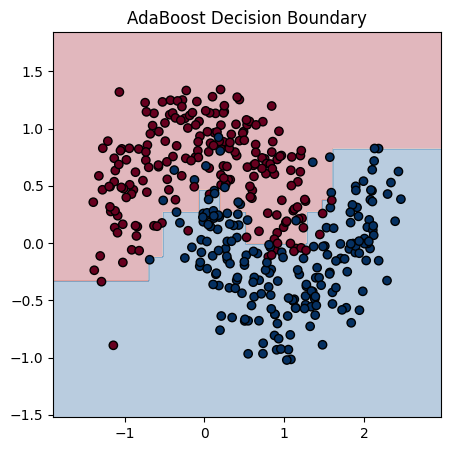

In [ ]:
ada_clf = AdaBoostClassifier(
    DecisionTreeClassifier(max_depth=1),  # weak learner (stump)
    n_estimators=100,
    learning_rate=0.5,
    random_state=42
)

ada_clf.fit(X_train, y_train)
y_pred = ada_clf.predict(X_test)
print(f"AdaBoost Accuracy: {accuracy_score(y_test, y_pred):.3f}")

plot_decision_boundary(ada_clf, X, y, "AdaBoost Decision Boundary")

## Summary

| Method | Main Idea | Bias | Variance | Interpretability |
|:--|:--|:--:|:--:|:--:|
| **Decision Tree** | Single interpretable model | Low | High | ✅ |
| **Voting Classifier** | Combine heterogeneous models | Medium | Medium | ⚙️ |
| **Bagging** | Average many base models | Medium | Low | ⚙️ |
| **Random Forest** | Bagging + feature randomness | Medium | Low | ⚙️ |
| **AdaBoost** | Sequentially correct errors | Low | Medium | ⚙️ |

**Key insight:**  
> Ensemble methods improve generalization by combining the strengths of multiple learners.  

Next step: experiment with **hyperparameters** (e.g., `n_estimators`, `max_depth`, `learning_rate`) to observe their impact.